# 2.2 数据清洗


> **这一节讲什么？**
> 
> 真实的金融数据很脏：有缺失值、异常跳价、未复权的价格跳变。这一节教你系统清洗数据——前向填充、异常值检测（3-sigma）、股票复权、多资产对齐，为后续分析铺路。

## 学习目标
- 识别并处理缺失值（填充 vs 插值）
- 检测和处理价格异常值（3-sigma 与 IQR）
- **严谨性：使用对数变换（Log Transform）压制噪声**
- 理解股票复权的必要性与方法
- 对齐不同资产的时间序列

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams['figure.figsize'] = (12, 4)

# 下载数据
raw = yf.download(['AAPL', 'MSFT', 'JPM'], start='2020-01-01',
                  end='2024-01-01', progress=False)['Close']
print(f'原始数据形状: {raw.shape}')
raw.head()

原始数据形状: (1006, 3)


Ticker,AAPL,JPM,MSFT
Date,,,
2020-01-02,72.400520,119.036415,152.158401
2020-01-03,71.696648,117.465553,150.263702
2020-01-06,72.267937,117.372162,150.652206
2020-01-07,71.928062,115.376770,149.278549
2020-01-08,73.085121,116.276817,151.656311


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 缺失值检测与处理

### 填充 vs 插值
- **前向填充 (ffill)**：最常用。假设没有新消息时，价格维持现状。这符合“不可预见未来”的原则。
- **线性插值 (interpolate)**：QuantEcon 在处理宏观经济模型（如连续时间模型）时常用，因为它能平滑序列。但在高频交易回测中要小心使用，因为它可能引入“未来信息”。

In [3]:
# 人为注入缺失值
data = raw.copy()
np.random.seed(42)
mask_rows = np.random.choice(len(data), 20, replace=False)
mask_cols = np.random.choice(len(data.columns), 20, replace=True)
for r, c in zip(mask_rows, mask_cols):
    data.iloc[r, c] = np.nan

# 推荐：日线数据常用前向填充
clean_data = data.ffill().bfill()
print(f'缺失值已处理，剩余 NaN: {clean_data.isnull().sum().sum()}')

缺失值已处理，剩余 NaN: 0


## 2. 异常值处理：对数变换与噪声压制

> **QuantEcon 严谨性提醒**：
> 
> 金融数据的波动往往是“等比”的（比如涨 5%）。如果在原始价格上算标准差，高股价时的波动会显著大于低股价时，这叫“异方差性”。
> 
> **处理技巧**：在检测异常值前，先取对数。对数收益率的分布通常比百分比收益率更接近对称，更容易识别出真正的离群点。

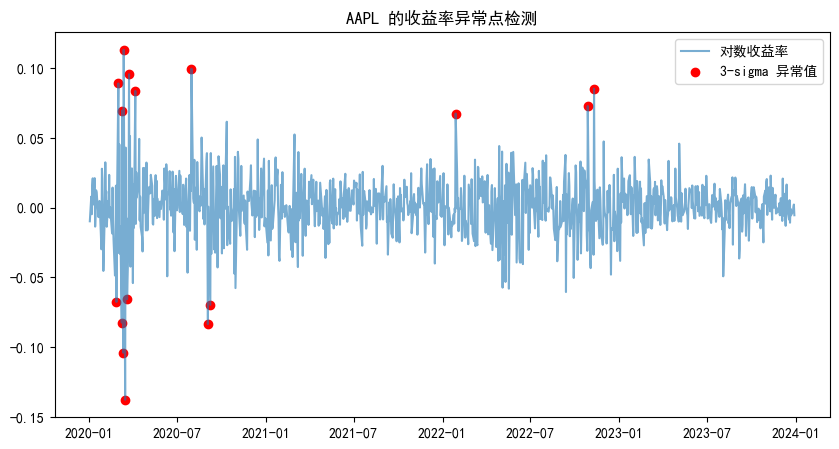

检测到 16 个极端波动点。


In [4]:
# 基于对数收益率的异常值检测
log_returns = np.log(clean_data / clean_data.shift(1)).dropna()

# 3-sigma 法则：识别出偏离平均值 3 个标准差以外的点
ticker = 'AAPL'
ret_series = log_returns[ticker]
mean, std = ret_series.mean(), ret_series.std()
outliers = ret_series[np.abs(ret_series - mean) > 3 * std]

plt.figure(figsize=(10, 5))
plt.plot(ret_series, label='对数收益率', alpha=0.6)
plt.scatter(outliers.index, outliers, color='red', label='3-sigma 异常值')
plt.title(f"{ticker} 的收益率异常点检测")
plt.legend()
plt.show()

print(f"检测到 {len(outliers)} 个极端波动点。")

## 3. 股票复权
复权是为了保证价格序列的**连续性**。分红或拆股后的价格跳变是“非市场行为”，如果不处理，回测会产生巨大的虚假亏损。

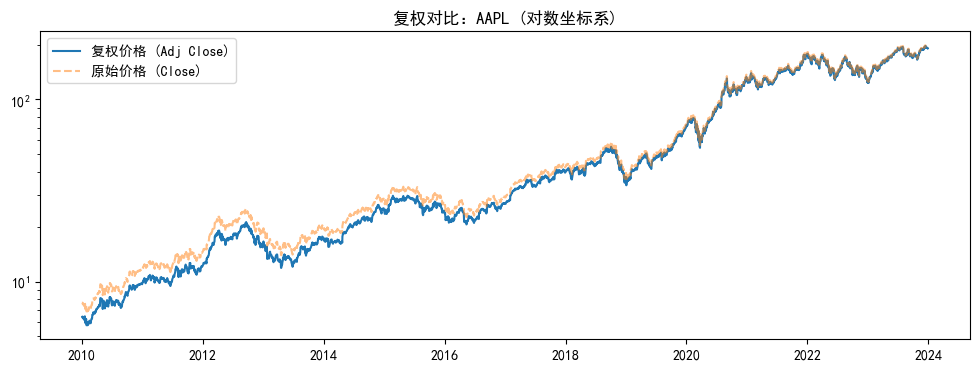

In [5]:
# 对比复权与不复权价格
aapl_adj = yf.download('AAPL', start='2010-01-01', end='2024-01-01', auto_adjust=True, progress=False)['Close']
aapl_raw = yf.download('AAPL', start='2010-01-01', end='2024-01-01', auto_adjust=False, progress=False)['Close']

plt.plot(aapl_adj, label='复权价格 (Adj Close)')
plt.plot(aapl_raw, label='原始价格 (Close)', alpha=0.5, linestyle='--')
plt.yscale('log') # 价格跨度大时，用对数轴观察更清晰
plt.title("复权对比：AAPL (对数坐标系)")
plt.legend()
plt.show()

## 4. 资产对齐：处理“非共同工作日”
美股和港股、A 股的节假日不同。在进行多市场策略回测时，必须对齐时间轴。常用做法是求交集（Inner Join）。

In [6]:
assets = yf.download(['AAPL', '0005.HK'], start='2023-01-01', end='2023-06-01', progress=False)['Close']
print(f"美股+港股 原始数据天数: {len(assets)}")

aligned = assets.dropna()
print(f"对齐（删除非共同交易日）后天数: {len(aligned)}")

美股+港股 原始数据天数: 106
对齐（删除非共同交易日）后天数: 96


## 🎯 练习

1. 尝试使用 `data.interpolate()` 处理缺失值，并对比它和 `ffill()` 在收益率计算上的区别。
2. 使用 `np.log(price).diff()` 来计算一次 SPY 的日收益率，并与 `price.pct_change()` 对比。
3. 检测 2020 年 3 月熔断期间，哪些交易日被视为统计学意义上的异常值（Z-score > 3）。

---
**下一节** → `03_feature_engineering.ipynb`
